### Building Customer Healthcare system

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/HP/Downloads/DA_proj_3/clean_saas_data.csv")

df.head()

,account_id,industry,country,seats,is_trial,churn_flag,total_feature_usage,avg_usage_duration,total_errors,beta_feature_usage,total_tickets,avg_resolution_time,avg_first_response,avg_satisfaction,escalation_count,total_mrr,total_arr,plan_type,billing_frequency,auto_renew
0,A-2e4581,EdTech,US,9,False,0,2140.0,2769.800000,152.0,16,220,23.000000,91.000000,3.000000,0,196760,2361120,Basic,monthly,True
1,A-5c046d,EdTech,FR,93,False,0,475.0,2781.000000,23.0,5,46,13.000000,128.000000,3.000000,0,563952,6767424,Basic,annual,True
2,A-f446b6,DevTools,DE,5,True,0,3008.0,3269.615385,248.0,24,312,30.750000,82.500000,4.250000,39,362688,4352256,Basic,annual,True
3,A-43a9e3,FinTech,IN,18,False,1,1065.0,2889.600000,42.0,6,105,38.000000,73.333333,4.000000,0,157209,1886508,Pro,annual,False
4,A-0a282f,DevTools,US,1,False,0,4926.0,3026.626506,288.0,30,498,43.666667,63.666667,4.666667,0,457968,5495616,Pro,annual,True


- Normalize Important Features
- We normalize values so that all metrics are on the same scale (0–1).

In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["usage_score"] = scaler.fit_transform(df[["total_feature_usage"]])
df["ticket_score"] = scaler.fit_transform(df[["total_tickets"]])
df["satisfaction_score"] = scaler.fit_transform(df[["avg_satisfaction"]])
df["revenue_score"] = scaler.fit_transform(df[["total_arr"]])

0 → lowest
1 → highest

In [3]:
#Calculate Customer Health Score
#combining matrices into one score

df["health_score"] = (
    0.4 * df["usage_score"] +
    0.3 * df["satisfaction_score"] +
    0.2 * df["revenue_score"] -
    0.1 * df["ticket_score"]
)

In [4]:
#convert score to percentage

df["health_score"] = df["health_score"] * 100

In [11]:
#Create Customer Health Category
def health_category(score):

    if score >= 35:
        return "Healthy"
    elif score >= 20:
        return "Neutral"
    else:
        return "At Risk"


df["health_status"] = df["health_score"].apply(health_category)

#### Chart 1: Customer Health Distribution

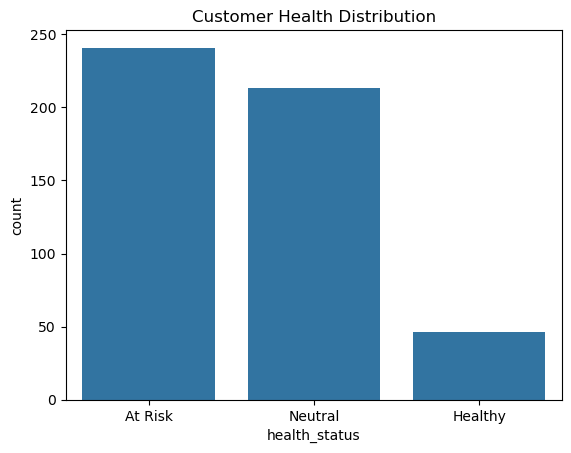

In [12]:
sns.countplot(x="health_status", data=df)

plt.title("Customer Health Distribution")
plt.show()

#### Chart 2: Health Score vs Churn

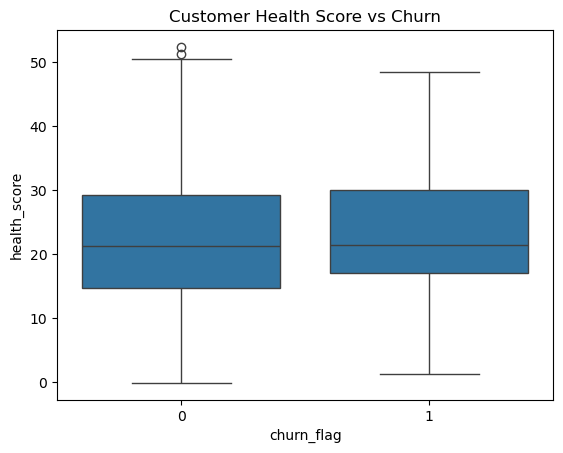

In [7]:
sns.boxplot(x="churn_flag", y="health_score", data=df)

plt.title("Customer Health Score vs Churn")
plt.show()

#### Chart 3: Industry Health Score

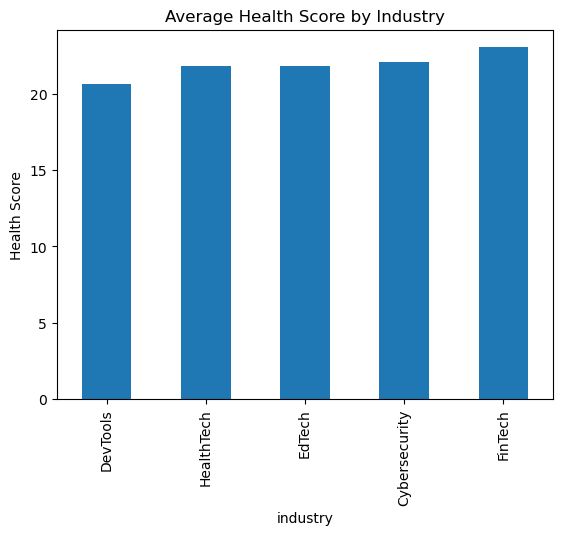

In [8]:
industry_health = df.groupby("industry")["health_score"].mean()

industry_health.sort_values().plot(kind="bar")

plt.title("Average Health Score by Industry")
plt.ylabel("Health Score")
plt.show()

#### Chart 4: Health Score vs Revenue

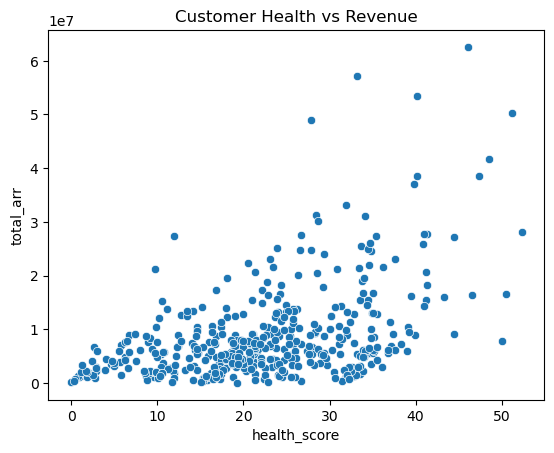

In [9]:
sns.scatterplot(x="health_score", y="total_arr", data=df)

plt.title("Customer Health vs Revenue")
plt.show()

#### Identify At-Risk High Value Customers

In [10]:
at_risk = df[(df["health_status"]=="At Risk") & (df["total_arr"]>10000)]

at_risk[["account_id","industry","total_arr","health_score"]].head()

,account_id,industry,total_arr,health_score
0,A-2e4581,EdTech,2361120,3.900278
1,A-5c046d,EdTech,6767424,2.573878
2,A-f446b6,DevTools,4352256,24.705003
3,A-43a9e3,FinTech,1886508,16.997864
4,A-0a282f,DevTools,5495616,34.551079


In [14]:
#Saving final dataset
df.to_csv("C:/Users/HP/Downloads/DA_proj_3/final_saas_dataset.csv", index=False)